# Predicción del precio de diamantes con regresión lineal y polinomial

**Objetivo:** predecir el precio de un diamante a partir de su peso y de sus cualidades de corte, color y claridad, comparando cuatro modelos de regresión de complejidad creciente.

**Resultado:** el modelo polinomial de grado 2 alcanza **R² 0.963** y **RMSE ≈ 749 USD** en el conjunto de prueba, frente a un R² de 0.846 del modelo base.

**Autor:** Alan Castro · Proyecto académico en equipo (4 integrantes)

---

## Datos

Se usa el conjunto de datos *diamonds*, disponible en el paquete ggplot2 de R y en repositorios públicos de análisis de datos: cerca de 54,000 diamantes con su precio y sus propiedades físicas.

| Variable | Descripción |
|---|---|
| `carat` | Peso del diamante en quilates |
| `cut` | Calidad del corte (Fair, Good, Very Good, Premium, Ideal) |
| `color` | Color del diamante, de D (mejor) a J (peor) |
| `clarity` | Claridad del diamante (I1, SI2, SI1, VS2, VS1, VVS2, VVS1, IF) |
| `depth` | Profundidad total como porcentaje: z / mean(x, y) |
| `table` | Ancho de la tabla (cara superior) relativo al punto más ancho, en porcentaje |
| `x`, `y`, `z` | Longitud, ancho y profundidad en mm |
| `price` | Precio en dólares estadounidenses (variable objetivo) |

In [1]:
# Importar las bibliotecas necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, RobustScaler
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import root_mean_squared_error, r2_score

sns.set_theme(style="whitegrid")

## 1. Carga y exploración inicial

Se cargan los datos y se revisan tipos de datos, valores únicos por columna, valores faltantes y registros duplicados.

In [2]:
diamonds_df = pd.read_csv("data/diamonds_dataset.csv")
diamonds_df.head()

,carat,cut,color,clarity,depth,table,x,y,z,price
0,0.23,Ideal,E,SI2,61.5,55.0,3.95,3.98,2.43,326
1,0.21,Premium,E,SI1,59.8,61.0,3.89,3.84,2.31,326
2,0.23,Good,E,VS1,56.9,65.0,4.05,4.07,2.31,327
3,0.29,Premium,I,VS2,62.4,58.0,4.20,4.23,2.63,334
4,0.31,Good,J,SI2,63.3,58.0,4.34,4.35,2.75,335


In [3]:
diamonds_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53916 entries, 0 to 53915
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53916 non-null  float64
 1   cut      53916 non-null  object 
 2   color    53916 non-null  object 
 3   clarity  53916 non-null  object 
 4   depth    53916 non-null  float64
 5   table    53916 non-null  float64
 6   x        53916 non-null  float64
 7   y        53916 non-null  float64
 8   z        53916 non-null  float64
 9   price    53916 non-null  int64  
dtypes: float64(6), int64(1), object(3)
memory usage: 4.1+ MB


In [4]:
diamonds_df.nunique()

,0
carat,271
cut,5
color,7
clarity,8
depth,184
table,127
x,550
y,549
z,371
price,11595


In [5]:
diamonds_df.isnull().sum()

,0
carat,0
cut,0
color,0
clarity,0
depth,0
table,0
x,0
y,0
z,0
price,0


In [6]:
print("Duplicados encontrados:", diamonds_df.duplicated().sum())

diamonds_df = diamonds_df.drop_duplicates().reset_index(drop=True)
print("Dimensiones tras eliminar duplicados:", diamonds_df.shape)

Duplicados encontrados: 145
Dimensiones tras eliminar duplicados: (53771, 10)


**Resultados:**

* **Tipos de datos:** el conjunto tiene **10 columnas**: **7 numéricas** (`carat`, `depth`, `table`, `x`, `y`, `z` en `float64` y `price` en `int64`) y **3 de texto** (`cut`, `color`, `clarity`, de tipo `object`).
* **Valores únicos:** las dimensiones físicas y el peso son casi continuos (`price` con ~11,595 valores únicos, `carat` con 271, `x/y/z` en cientos), mientras que las categóricas tienen pocos niveles: `cut` = 5, `color` = 7 y `clarity` = 8.
* **Valores faltantes:** ninguna columna contiene nulos.
* **Duplicados:** se detectaron **145 registros duplicados**, que se eliminaron, dejando el dataframe con **53,771 registros** y el índice reiniciado de forma consecutiva.

## 2. Estadísticas descriptivas y análisis univariado

Estadísticas descriptivas por tipo de variable, tablas de frecuencia para las categóricas, y distribuciones con histogramas, boxplots y diagramas de barras.

In [7]:
num_cols = diamonds_df.select_dtypes(include=np.number).columns.tolist()
cat_cols = diamonds_df.select_dtypes(exclude=np.number).columns.tolist()
print("Numéricas:", num_cols)
print("Categóricas:", cat_cols)

Numéricas: ['carat', 'depth', 'table', 'x', 'y', 'z', 'price']
Categóricas: ['cut', 'color', 'clarity']


In [8]:
diamonds_df[num_cols].describe().T.style.format("{:.2f}")

,count,mean,std,min,25%,50%,75%,max
carat,53771.00,0.80,0.47,0.20,0.40,0.70,1.04,4.50
depth,53771.00,61.75,1.43,43.00,61.00,61.80,62.50,79.00
table,53771.00,57.46,2.23,43.00,56.00,57.00,59.00,95.00
x,53771.00,5.73,1.12,3.73,4.71,5.70,6.54,10.23
y,53771.00,5.73,1.14,3.68,4.72,5.71,6.54,58.90
z,53771.00,3.54,0.70,1.07,2.91,3.53,4.03,31.80
price,53771.00,3930.32,3984.69,326.00,951.00,2401.00,5323.50,18823.00


In [9]:
diamonds_df[cat_cols].describe().T

,count,unique,top,freq
cut,53771,5,Ideal,21485
color,53771,7,G,11254
clarity,53771,8,SI1,13030


In [10]:
for col in cat_cols:
    freq = (diamonds_df[col].value_counts()
            .rename_axis(col)
            .reset_index(name="frecuencia"))
    freq["porcentaje"] = (100 * freq["frecuencia"] / len(diamonds_df)).round(2)
    display(freq)

,cut,frecuencia,porcentaje
0,Ideal,21485,39.96
1,Premium,13737,25.55
2,Very Good,12065,22.44
3,Good,4888,9.09
4,Fair,1596,2.97


,color,frecuencia,porcentaje
0,G,11254,20.93
1,E,9776,18.18
2,F,9517,17.70
3,H,8266,15.37
4,D,6753,12.56
5,I,5404,10.05
6,J,2801,5.21


,clarity,frecuencia,porcentaje
0,SI1,13030,24.23
1,VS2,12225,22.74
2,SI2,9140,17.00
3,VS1,8155,15.17
4,VVS2,5056,9.40
5,VVS1,3646,6.78
6,IF,1784,3.32
7,I1,735,1.37


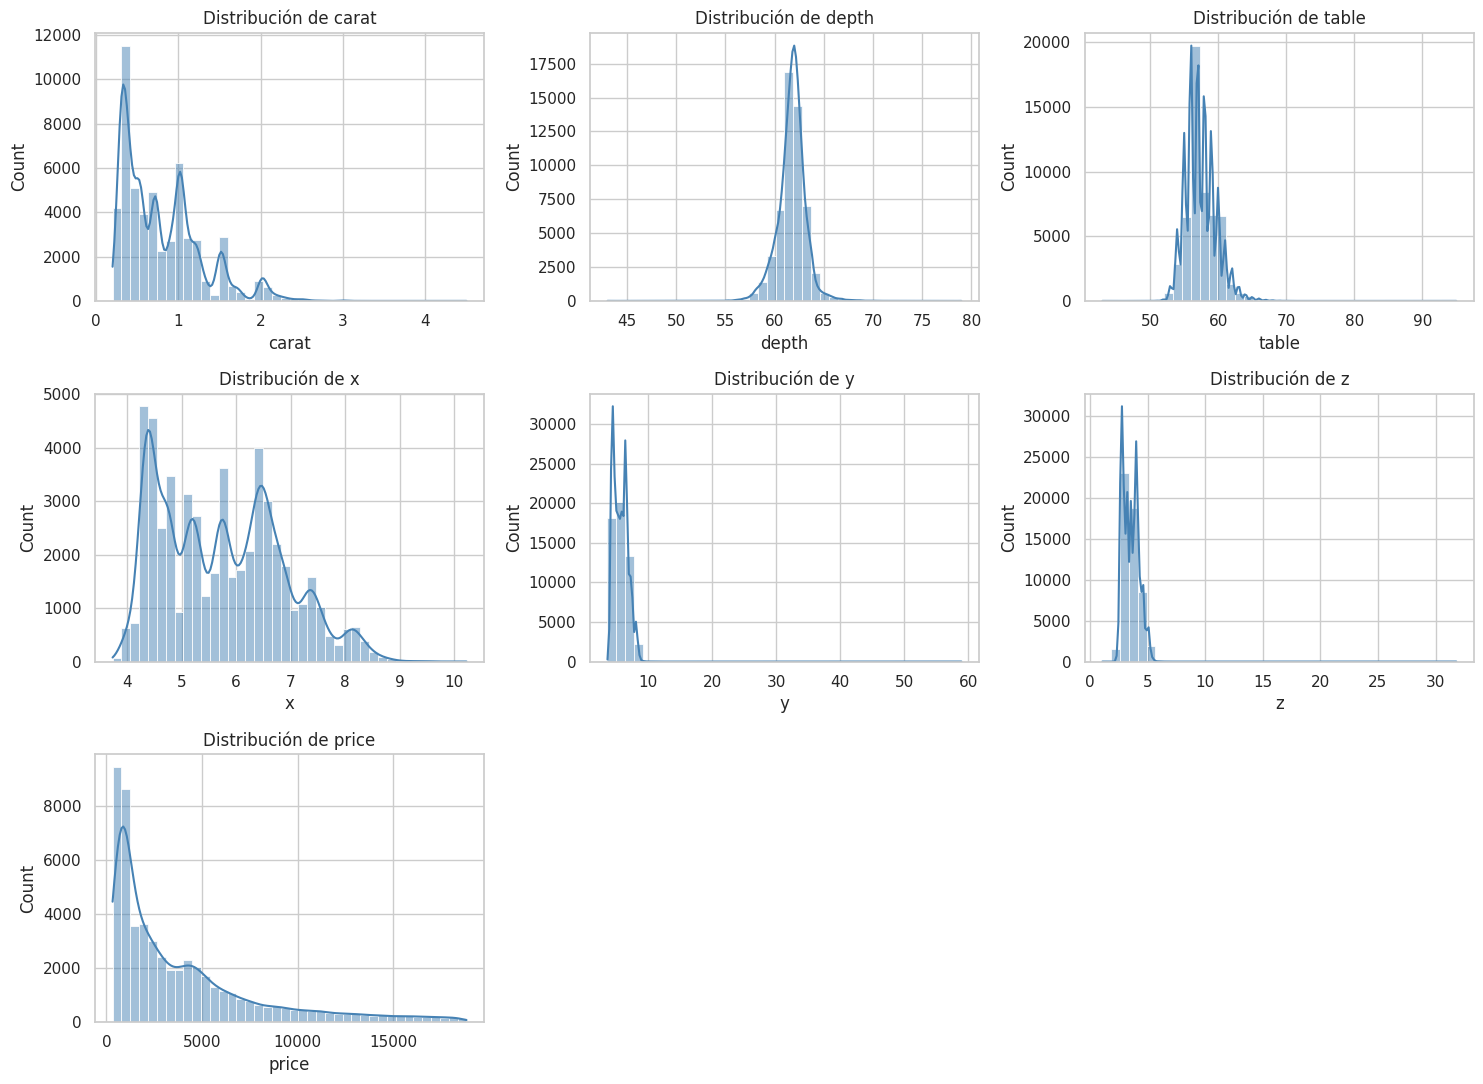

In [11]:
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
for ax, col in zip(axes.ravel(), num_cols):
    sns.histplot(diamonds_df[col], bins=40, kde=True, ax=ax, color="steelblue")
    ax.set_title(f"Distribución de {col}")
for ax in axes.ravel()[len(num_cols):]:
    ax.set_visible(False)
fig.tight_layout()
plt.show()

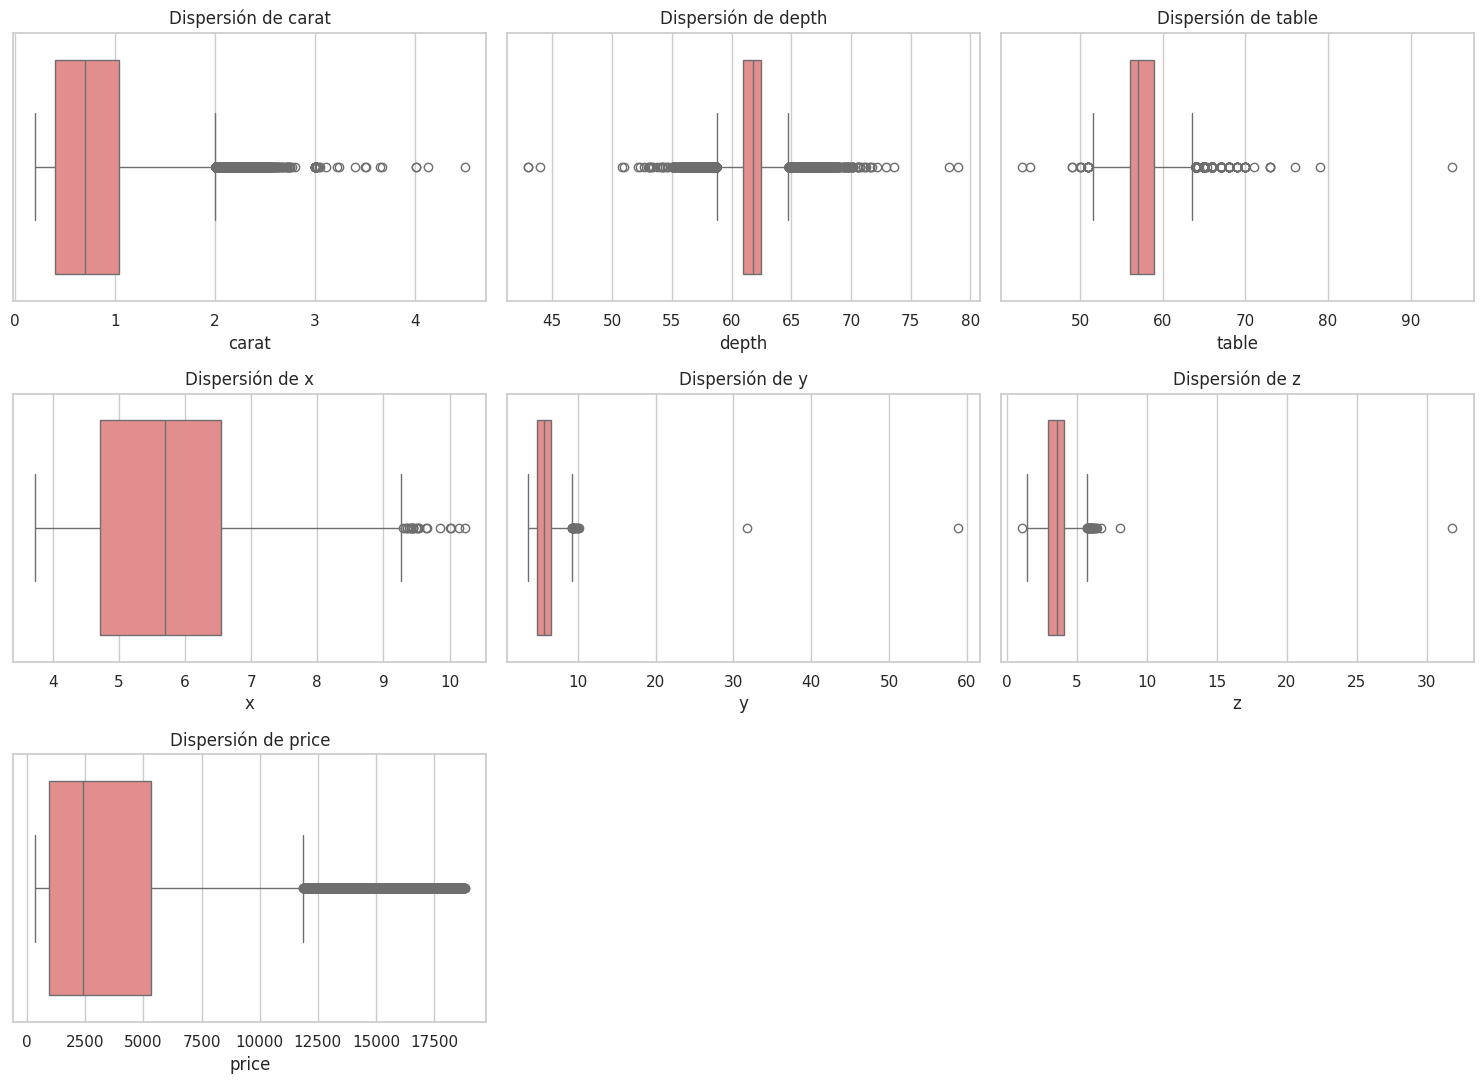

In [12]:
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
for ax, col in zip(axes.ravel(), num_cols):
    sns.boxplot(x=diamonds_df[col], ax=ax, color="lightcoral")
    ax.set_title(f"Dispersión de {col}")
for ax in axes.ravel()[len(num_cols):]:
    ax.set_visible(False)
fig.tight_layout()
plt.show()

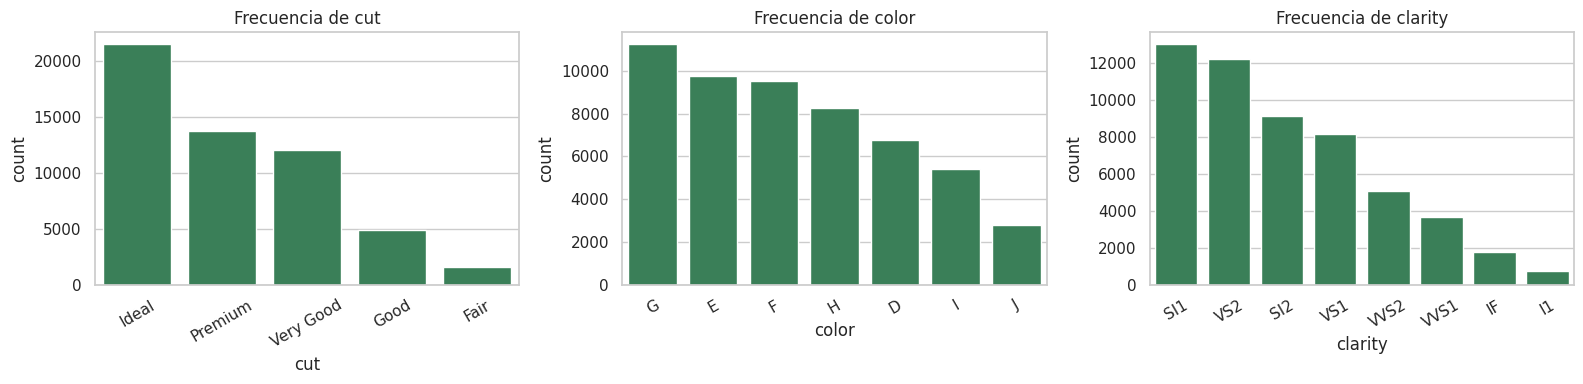

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, cat_cols):
    order = diamonds_df[col].value_counts().index
    sns.countplot(data=diamonds_df, x=col, order=order, ax=ax, color="seagreen")
    ax.set_title(f"Frecuencia de {col}")
    ax.tick_params(axis="x", rotation=30)
fig.tight_layout()
plt.show()

**Observaciones del análisis univariado:**

* **`price` y `carat` están fuertemente sesgadas a la derecha:** la mayoría de los diamantes son pequeños y baratos, con una cola larga de piezas grandes y costosas. Esto anticipa que una relación lineal pura tendrá limitaciones y que una transformación polinomial podría ayudar.
* **`x`, `y`, `z`** (dimensiones físicas) muestran distribuciones similares entre sí, lo que sugiere que aportan información redundante respecto al tamaño (se confirmará en la matriz de correlación).
* **`depth` y `table`** son aproximadamente simétricas y concentradas, con valores atípicos puntuales que reflejan tallados poco comunes.
* **Categóricas:** el corte `Ideal` es el más frecuente, los colores se concentran en los tonos intermedios (G, E, F) y la claridad predominante es `SI1`/`VS2`. Las categorías de menor calidad (`Fair`, `I1`) son escasas.

## 3. Análisis bivariado

Se analiza cómo varía el precio según el color (ordenado de mejor a peor, de D a J) y la relación entre el precio y el peso según la calidad del corte.

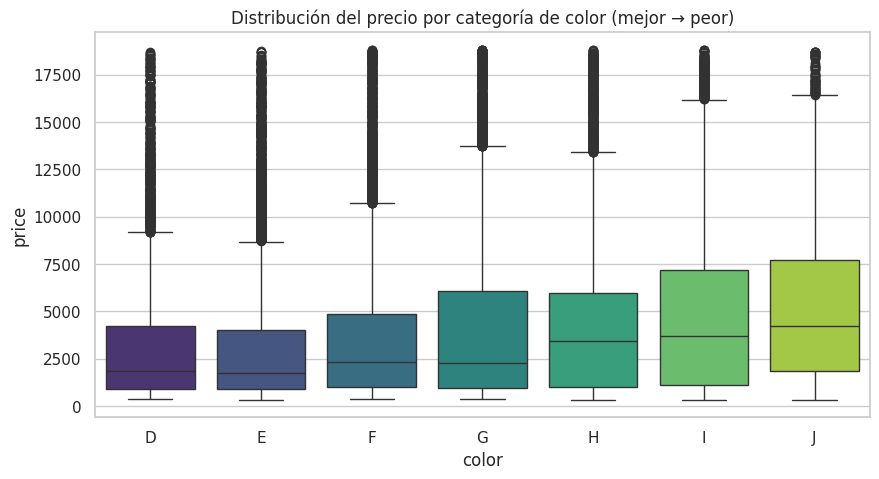

In [14]:
color_order = ["D", "E", "F", "G", "H", "I", "J"]
plt.figure(figsize=(10, 5))
sns.boxplot(data=diamonds_df, x="color", y="price", order=color_order,
            hue="color", hue_order=color_order, palette="viridis", legend=False)
plt.title("Distribución del precio por categoría de color (mejor → peor)")
plt.show()

In [15]:
diamonds_df.groupby("color")["carat"].mean().reindex(color_order).round(3)

,carat
color,
D,0.658
E,0.658
F,0.737
G,0.771
H,0.910
I,1.024
J,1.161


**¿La tendencia de precios se comporta como se esperaba?**

No. Intuitivamente, el color D (el mejor) debería ser el más caro y J (el peor) el más barato, pero los boxplots muestran lo **contrario**: el precio mediano **aumenta** conforme el color empeora de D hacia J.

**Variable que influye en la tendencia (confundidor):** el **peso (`carat`)**. El quilataje medio crece de forma monótona desde ~0.66 en color D hasta ~1.16 en color J. Es decir, en este conjunto los diamantes de peor color tienden a ser mucho más grandes. Como el peso es, por mucho, el principal determinante del precio, su efecto **domina y enmascara** el efecto real del color. Si se comparara el precio a igualdad de peso, sí aparecería la prima esperada por mejor color. Es un ejemplo clásico de variable de confusión.

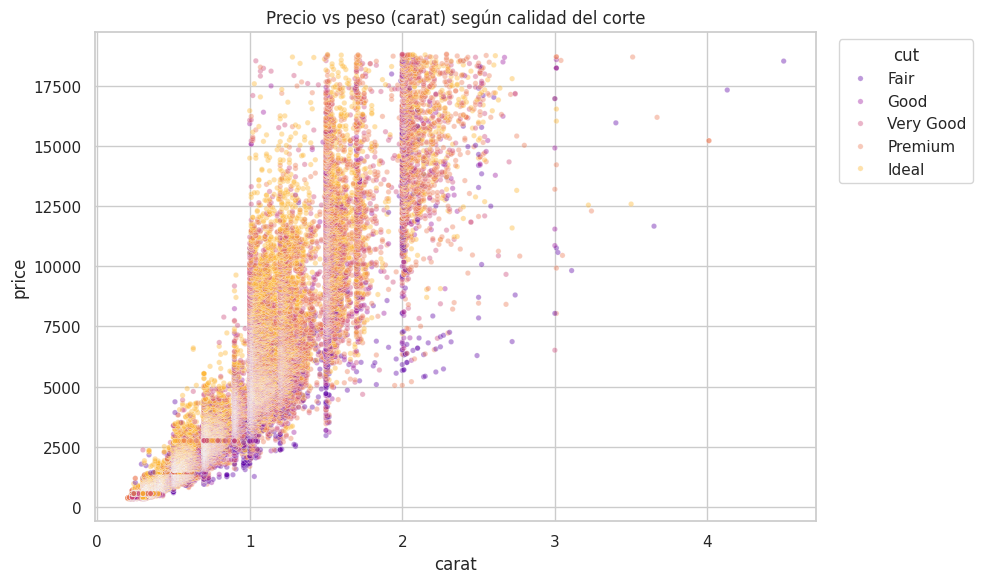

In [16]:
cut_order = ["Fair", "Good", "Very Good", "Premium", "Ideal"]
plt.figure(figsize=(10, 6))
sns.scatterplot(data=diamonds_df, x="carat", y="price", hue="cut",
                hue_order=cut_order, alpha=0.4, s=15, palette="plasma")
plt.title("Precio vs peso (carat) según calidad del corte")
plt.legend(title="cut", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

**Relación entre peso y precio según el corte:**

Existe una relación **positiva y fuerte** entre el peso y el precio: a mayor `carat`, mayor `price`. La nube de puntos no es perfectamente lineal sino **curvada hacia arriba** (convexa), lo que indica que el precio crece más que proporcionalmente con el peso — otra señal a favor del modelo polinomial.

Respecto al corte, para un mismo peso los diamantes con mejor talla (`Ideal`, `Premium`) tienden a ubicarse en la parte alta de la nube, alcanzando precios superiores, mientras que los `Fair` quedan por debajo. El efecto del corte es real pero **mucho más sutil** que el del peso, que es el factor dominante.

## 4. Matriz de correlación y reducción de redundancia

Se identifican los pares de variables numéricas con correlación superior a 0.9 y se eliminan los predictores redundantes para simplificar los modelos.

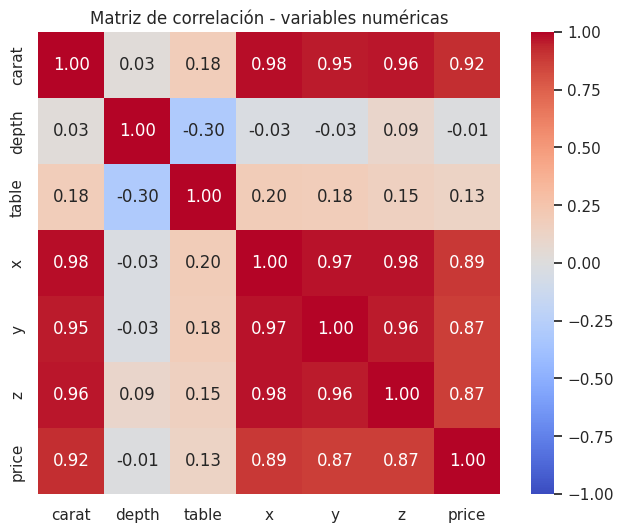

In [17]:
corr = diamonds_df[num_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True)
plt.title("Matriz de correlación - variables numéricas")
plt.show()

In [18]:
predictors_corr = diamonds_df[num_cols].drop(columns="price").corr()
high_pairs = []
cols = predictors_corr.columns
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        r = predictors_corr.iloc[i, j]
        if abs(r) > 0.9:
            high_pairs.append((cols[i], cols[j], round(r, 4)))

print("Pares con |correlación| > 0.9:")
for a, b, r in high_pairs:
    print(f"  {a} - {b}: {r}")

Pares con |correlación| > 0.9:
  carat - x: 0.9781
  carat - y: 0.9542
  carat - z: 0.9612
  x - y: 0.9748
  x - z: 0.9754
  y - z: 0.9566


In [19]:
diamonds_df[num_cols].corr()["price"].drop("price").sort_values(ascending=False)

,price
carat,0.921846
x,0.887058
z,0.867942
y,0.867588
table,0.126497
depth,-0.011336


**Análisis de redundancia:**

Las variables `carat`, `x`, `y` y `z` forman un bloque altamente correlacionado entre sí (todas con |r| > 0.95), porque las tres dimensiones físicas (`x`, `y`, `z`) **determinan directamente el peso**. Es decir, un único predictor —`carat`— captura prácticamente la misma información de tamaño que está repartida en `x`, `y` y `z`.

Además, `carat` es el predictor con **mayor correlación individual con `price` (0.92)**, por encima de `x`, `z` y `y`. Por lo tanto, se conserva `carat` y se eliminan `x`, `y` y `z` para reducir la multicolinealidad y simplificar los modelos.

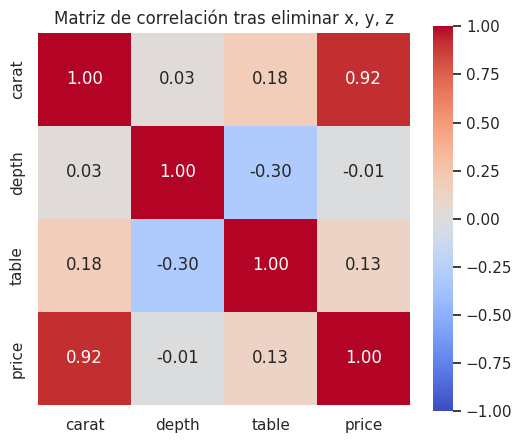

In [20]:
diamonds_df = diamonds_df.drop(columns=["x", "y", "z"])

num_cols = diamonds_df.select_dtypes(include=np.number).columns.tolist()
plt.figure(figsize=(6, 5))
sns.heatmap(diamonds_df[num_cols].corr(), annot=True, fmt=".2f",
            cmap="coolwarm", vmin=-1, vmax=1, square=True)
plt.title("Matriz de correlación tras eliminar x, y, z")
plt.show()

**Verificación:** tras eliminar `x`, `y` y `z`, la correlación máxima entre los predictores restantes (`carat`, `depth`, `table`) cae a ~0.30, por lo que ya no existe multicolinealidad relevante.

## 5. Modelo de regresión lineal simple (Baseline)

Modelo base con un solo predictor: la variable con mayor correlación con `price`. Los datos se dividen en entrenamiento y prueba (80:20, `random_state=1`) y el modelo se evalúa con RMSE y R².

In [21]:
X = diamonds_df[["carat"]]
y = diamonds_df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1)

baseline = LinearRegression()
baseline.fit(X_train, y_train)
y_pred = baseline.predict(X_test)

rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

results = pd.DataFrame([{"Modelo": "Baseline", "RMSE": rmse, "R2": r2}])
results

,Modelo,RMSE,R2
0,Baseline,1532.43849,0.84618


In [22]:
intercepto = baseline.intercept_
coef = baseline.coef_[0]
print(f"price = {intercepto:.2f} + {coef:.2f} x carat")

price = -2276.79 + 7792.73 x carat


**Interpretación:** el modelo base, usando solo el peso, alcanza un **R² ≈ 0.85**, lo que confirma que `carat` por sí solo explica la mayor parte de la variación del precio. La ecuación indica que, en promedio, cada quilate adicional incrementa el precio en ~\$7,793. El intercepto negativo no tiene sentido físico (un diamante de 0 quilates no cuesta dinero negativo); es solo el ajuste matemático de la recta y refleja que la relación real es curva, no estrictamente lineal.

## 6. Modelo lineal múltiple — Ordinal + Robust

Se usan todos los predictores, con escalamiento robusto para las variables numéricas y codificación ordinal para las categóricas, respetando el orden de calidad de cada una.

In [23]:
X = diamonds_df.drop(columns="price")
y = diamonds_df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1)

cut_order     = ["Fair", "Good", "Very Good", "Premium", "Ideal"]
color_order   = ["J", "I", "H", "G", "F", "E", "D"]
clarity_order = ["I1", "SI2", "SI1", "VS2", "VS1", "VVS2", "VVS1", "IF"]

preprocessing = ColumnTransformer([
    ("num", RobustScaler(), make_column_selector(dtype_include=np.number)),
    ("cat", OrdinalEncoder(categories=[cut_order, color_order, clarity_order]),
            ["cut", "color", "clarity"])
])

pipe_ordinal = make_pipeline(preprocessing, LinearRegression())
pipe_ordinal.fit(X_train, y_train)
y_pred = pipe_ordinal.predict(X_test)

results.loc[len(results)] = ["Ordinal_Robust",
                             root_mean_squared_error(y_test, y_pred),
                             r2_score(y_test, y_pred)]
results

,Modelo,RMSE,R2
0,Baseline,1532.438490,0.846180
1,Ordinal_Robust,1216.822219,0.903016


**Interpretación:** al incorporar todas las variables (incluyendo `cut`, `color` y `clarity` codificadas en su orden de calidad), el **R² sube a ~0.90**. El escalamiento robusto reduce el impacto de los valores atípicos de peso y dimensiones. La codificación ordinal asume que el efecto de subir un nivel de calidad es constante, lo cual es una simplificación que el siguiente modelo (one-hot) flexibiliza.

## 7. Modelo lineal múltiple — OHE + MinMax

Variante con escalamiento Min-Max para las variables numéricas y codificación one-hot para las categóricas, con `drop='first'` para prevenir multicolinealidad.

In [24]:
preprocessing2 = ColumnTransformer([
    ("num", MinMaxScaler(), make_column_selector(dtype_include=np.number)),
    ("cat", OneHotEncoder(drop="first"), make_column_selector(dtype_exclude=np.number))
])

pipe_ohe = make_pipeline(preprocessing2, LinearRegression())
pipe_ohe.fit(X_train, y_train)
y_pred = pipe_ohe.predict(X_test)

results.loc[len(results)] = ["OHE_MinMax",
                             root_mean_squared_error(y_test, y_pred),
                             r2_score(y_test, y_pred)]
results

,Modelo,RMSE,R2
0,Baseline,1532.438490,0.846180
1,Ordinal_Robust,1216.822219,0.903016
2,OHE_MinMax,1142.519131,0.914499


**Interpretación:** la codificación one-hot permite que cada categoría tenga su propio coeficiente, sin imponer una progresión lineal entre niveles. Esto mejora ligeramente el ajuste frente al modelo ordinal (**R² ~0.91**), capturando mejor las diferencias no uniformes entre categorías de corte, color y claridad.

## 8. Modelo de regresión polinomial (grado 2)

Se añade una expansión polinomial de segundo grado al pipeline anterior para evaluar si mejora el ajuste.

In [25]:
pipe_poly = make_pipeline(preprocessing2,
                          PolynomialFeatures(degree=2, include_bias=False),
                          LinearRegression())
pipe_poly.fit(X_train, y_train)
y_pred = pipe_poly.predict(X_test)

results.loc[len(results)] = ["PolynomialDegree2",
                             root_mean_squared_error(y_test, y_pred),
                             r2_score(y_test, y_pred)]
results

,Modelo,RMSE,R2
0,Baseline,1532.438490,0.846180
1,Ordinal_Robust,1216.822219,0.903016
2,OHE_MinMax,1142.519131,0.914499
3,PolynomialDegree2,749.026278,0.963251


**Interpretación:** la expansión polinomial de grado 2 introduce términos cuadráticos (como `carat²`) e interacciones entre variables (por ejemplo `carat × clarity`). Esto captura la curvatura que ya habíamos detectado en el análisis bivariado, y el ajuste mejora de forma notable: **R² ~0.96** y el menor RMSE de todos los modelos. Es el mejor desempeño obtenido.

## 9. Comparativa y visualización del mejor modelo

Se ordenan los modelos por R² y, para el mejor, se grafican los valores reales frente a los predichos con una diagonal de referencia (predicción perfecta).

In [26]:
results = results.sort_values("R2", ascending=False).reset_index(drop=True)
results

,Modelo,RMSE,R2
0,PolynomialDegree2,749.026278,0.963251
1,OHE_MinMax,1142.519131,0.914499
2,Ordinal_Robust,1216.822219,0.903016
3,Baseline,1532.438490,0.846180


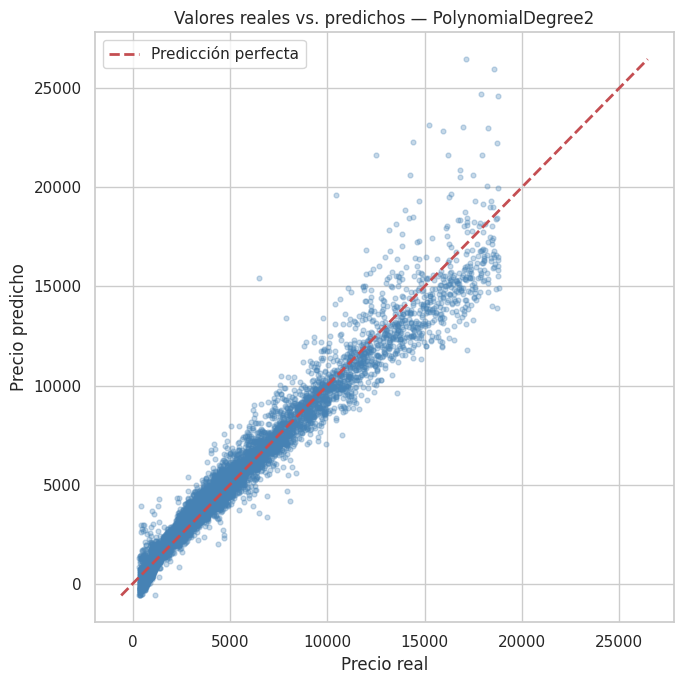

In [27]:
y_pred_best = pipe_poly.predict(X_test)

plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred_best, alpha=0.3, s=12, color="steelblue")
lims = [min(y_test.min(), y_pred_best.min()), max(y_test.max(), y_pred_best.max())]
plt.plot(lims, lims, "r--", lw=2, label="Predicción perfecta")
plt.xlabel("Precio real")
plt.ylabel("Precio predicho")
plt.title("Valores reales vs. predichos — PolynomialDegree2")
plt.legend()
plt.tight_layout()
plt.show()

**Interpretación:** el modelo polinomial de grado 2 es el de mejor desempeño. En el gráfico, los puntos se agrupan de forma cercana a la diagonal de predicción perfecta, especialmente en el rango de precios bajos y medios donde se concentran la mayoría de los diamantes. La dispersión aumenta para precios altos, donde hay menos datos y mayor variabilidad.

## 10. Interpretación del modelo

Se muestra el diagrama del pipeline y se recuperan los nombres de las columnas tras el preprocesamiento y la expansión polinomial, junto con los coeficientes y el intercepto, para identificar los 10 términos más influyentes.

In [28]:
from sklearn import set_config
set_config(display="diagram")
pipe_poly

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('num', MinMaxScaler(),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7ed25c70cec0>),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7ed25c70cf50>)])),
                ('polynomialfeatures', PolynomialFeatures(include_bias=False)),
                ('linearregression', LinearRegression())])

In [29]:
feature_names_pre = pipe_poly.named_steps["columntransformer"].get_feature_names_out()
print(f"Columnas tras el preprocesamiento ({len(feature_names_pre)}):")
print(list(feature_names_pre))

Columnas tras el preprocesamiento (20):
['num__carat', 'num__depth', 'num__table', 'cat__cut_Good', 'cat__cut_Ideal', 'cat__cut_Premium', 'cat__cut_Very Good', 'cat__color_E', 'cat__color_F', 'cat__color_G', 'cat__color_H', 'cat__color_I', 'cat__color_J', 'cat__clarity_IF', 'cat__clarity_SI1', 'cat__clarity_SI2', 'cat__clarity_VS1', 'cat__clarity_VS2', 'cat__clarity_VVS1', 'cat__clarity_VVS2']


In [30]:
feature_names_poly = (pipe_poly.named_steps["polynomialfeatures"]
                      .get_feature_names_out(feature_names_pre))
print(f"Columnas tras la expansión polinomial: {len(feature_names_poly)}")
print(list(feature_names_poly[:15]), "...")

Columnas tras la expansión polinomial: 230
['num__carat', 'num__depth', 'num__table', 'cat__cut_Good', 'cat__cut_Ideal', 'cat__cut_Premium', 'cat__cut_Very Good', 'cat__color_E', 'cat__color_F', 'cat__color_G', 'cat__color_H', 'cat__color_I', 'cat__color_J', 'cat__clarity_IF', 'cat__clarity_SI1'] ...


In [31]:
lr = pipe_poly.named_steps["linearregression"]
print(f"Intercepto: {lr.intercept_:.2f}")

coeffs = pd.DataFrame({"feature": feature_names_poly, "coeficiente": lr.coef_})
coeffs["abs"] = coeffs["coeficiente"].abs()
top10 = coeffs.sort_values("abs", ascending=False).head(10).drop(columns="abs")
top10.reset_index(drop=True)

Intercepto: -907.01


,feature,coeficiente
0,num__carat^2,55138.858509
1,num__carat cat__clarity_IF,49901.936113
2,num__carat cat__clarity_VVS1,46676.323033
3,num__carat cat__clarity_VVS2,44778.304459
4,num__carat cat__clarity_VS1,40030.092696
5,num__carat cat__clarity_VS2,37092.587930
6,num__carat cat__clarity_SI1,31996.751829
7,num__carat cat__clarity_SI2,24370.331563
8,num__carat cat__color_J,-20648.289435
9,num__carat cat__color_I,-14267.848139


**Conclusiones sobre cómo influyen los factores en el precio:**

* **El peso es el motor del precio, y de forma no lineal.** El término `carat²` es el coeficiente más grande y positivo: el precio crece más que proporcionalmente con el tamaño, confirmando la curvatura observada en el análisis bivariado.
* **La claridad amplifica el valor del peso.** Las interacciones `carat × clarity_IF`, `carat × clarity_VVS1`, `carat × clarity_VVS2` tienen coeficientes positivos grandes: una piedra grande **y** muy limpia se cotiza con una fuerte prima. El efecto de la claridad no es independiente del tamaño, sino multiplicativo.
* **El color de baja calidad penaliza el precio por quilate.** Las interacciones `carat × color_J` y `carat × color_I` aparecen con coeficientes **negativos**: a igualdad de peso, los colores peores reducen el precio. Esto resuelve la aparente paradoja de la sección 3 — una vez que el modelo controla por el peso, el peor color sí abarata el diamante, como se esperaba.
* **En conjunto**, el precio queda explicado principalmente por el tamaño, modulado por las interacciones del tamaño con la calidad (claridad y color). El corte tiene un peso secundario frente a estos factores.

---

**Declaración de uso de IA**

Google. (2026). Gemini (basado en Gemini 3.1) [Modelo de lenguaje grande], utilizado para optimización y depuración de código. https://gemini.google.com


---